In [73]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import L_BFGS_B
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.optimizers import SPSA 
from qiskit_aer import AerSimulator
from sklearn.model_selection import train_test_split

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_ibm_runtime import SamplerV2 as Sampler


In [74]:
# ── Configuration ─────────────────────────────────────────────────────────────

# Dataset
n          = 500   # Number of generated points
TEST_SIZE  = 0.2    # Fraction used for test set
SEED       = 1      # Random seed (data split & optimizer init)
N_DIM      = 3     # Features dimension

# Optimization
MAXITER    = 200     # minimizer max iterations
optimizer = COBYLA(maxiter=MAXITER) 

# Noise 
USE_NOISE = True 
NOISE_RATE = 0.02
# ──────────────────────────────────────────────────────────────────────────────


In [75]:
if USE_NOISE:
    print("Construction du simulateur BRUITÉ...")
    nm = NoiseModel()
    # Erreur sur les portes simples (1 qubit)
    err1 = depolarizing_error(NOISE_RATE, 1)
    nm.add_all_qubit_quantum_error(err1, ['u', 'h', 'ry', 'rz'])
    # Erreur sur l'intrication (2 qubits) - on met souvent 5x plus
    err2 = depolarizing_error(NOISE_RATE * 5, 2)
    nm.add_all_qubit_quantum_error(err2, ['cx'])
    
    # On crée le backend (ton ancien AerSimulator)
    backend = AerSimulator(noise_model=nm, method="density_matrix")
    # On l'enveloppe pour le rendre compatible VQC
    sampler = Sampler(backend)
else:
    print("-> Mode IDÉAL")
    sampler = Sampler(AerSimulator())

Construction du simulateur BRUITÉ...


In [76]:
def generate_nsphere_data(n_samples, n_dim, radius=None):
    # Génération de points entre -1 et 1
    X = np.random.uniform(-1, 1, (n_samples, n_dim))    
    # Le rayon par défaut est choisi pour équilibrer les classes
    if radius is None:
        radius = np.sqrt(n_dim / 3) 
        
    # Calcul de la norme euclidienne au carré
    dist_sq = np.sum(X**2, axis=1)
    y = (dist_sq >= radius**2).astype(int)
    
    return X, y, radius



In [77]:
X, y, R = generate_nsphere_data(n_samples=n, n_dim=N_DIM)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(X_train.shape, y_train.shape)

(400, 3) (400,)


## VQC

In [78]:
iteration = 0
def callback(*args):
    global iteration
    iteration += 1 
    print(f"Iteration {iteration}")

In [79]:
feature_map = zz_feature_map(feature_dimension=N_DIM, reps=2)
ansatz = real_amplitudes(num_qubits=N_DIM, reps=2)

vqc = VQC(feature_map=feature_map, ansatz=ansatz, optimizer=optimizer, callback=callback)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


## Training

In [80]:
print(f"Entraînement sur une {N_DIM}-sphère...")
vqc.fit(X_train, y_train )

Entraînement sur une 3-sphère...


## VQC Results 

In [81]:
accuracy = vqc.score(X_test, y_test)
y_pred = vqc.predict(X_test)
print(f"Précision sur le test: {accuracy*100} %")

Précision sur le test: 59.0 %


### VQC circuit

--- FEATURE MAP ---


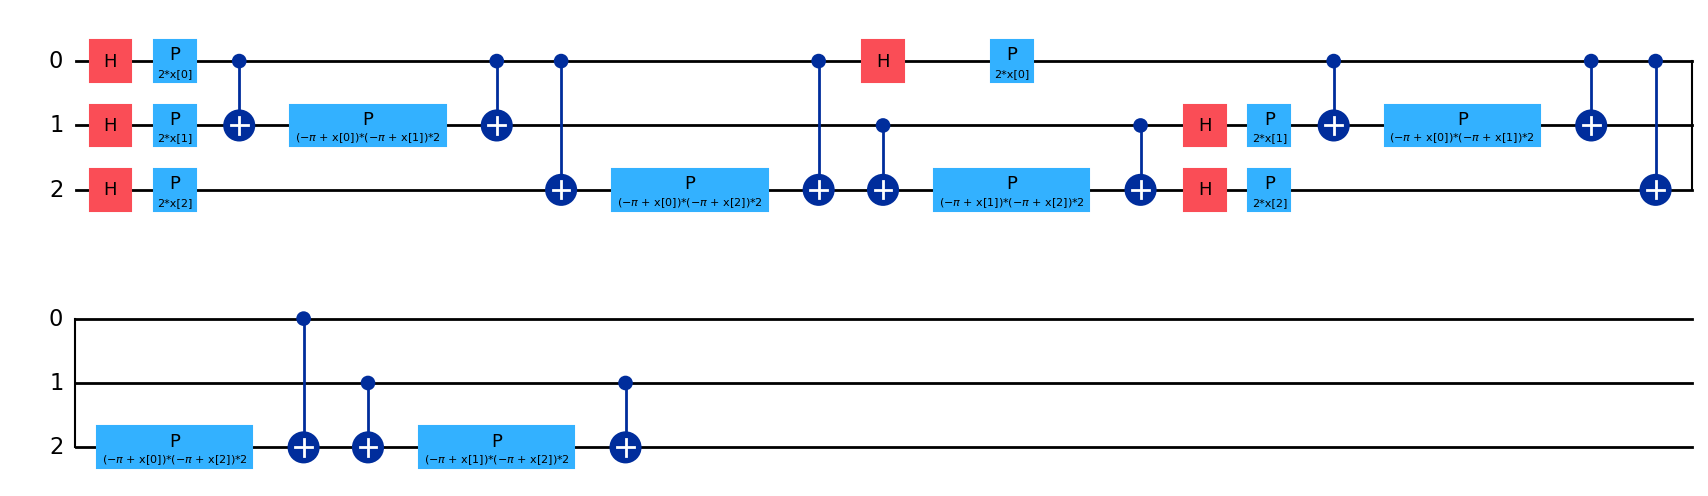

In [82]:
# 1. Visualiser comment les données N-dim sont encodées
print("--- FEATURE MAP ---")
vqc.feature_map.draw('mpl')



--- ANSATZ ---


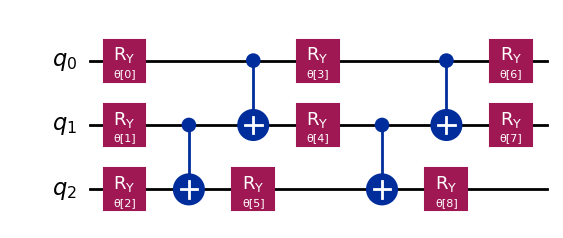

In [83]:
# 2. Visualiser la structure d'entraînement (les couches de rotation et CNOT)
print("--- ANSATZ ---")
vqc.ansatz.draw('mpl')

### Visualisation si dim=2 ou 3 

In [84]:
def plot_2d() : 
    pred1 = X_test[y_pred == 1]
    pred0 = X_test[y_pred == 0]

    plt.scatter(pred0[:,0],pred0[:,1], color = 'red', label='pred0')
    plt.scatter(pred1[:,0],pred1[:,1], color = 'blue', label='pred1')


    circle_rad = np.sqrt(N_DIM/3) # rayon par défaut, à modifier si le rayon est changé
    circle = plt.Circle((0, 0), circle_rad, color='black', fill=False, 
                        linestyle='--', linewidth=2, label='Frontière réelle')
    plt.gca().add_artist(circle)

    # Configuration du graphique
    plt.title(f"Visualisation des performances ({accuracy*100}%)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axhline(0, color='black', linewidth=0.5, alpha=0.5)
    plt.axvline(0, color='black', linewidth=0.5, alpha=0.5)
    plt.legend(loc='upper right')
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.show()
    
def plot_3d() :
    from mpl_toolkits.mplot3d import Axes3D
 
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Masques pour séparer les résultats
    pred1 = X_test[y_pred == 1]
    pred0 = X_test[y_pred == 0]

    ax.scatter(pred0[:,0],pred0[:,1],pred0[:,2], color = 'red', label='pred0')
    ax.scatter(pred1[:,0],pred1[:,1],pred1[:,2], color = 'blue', label='pred1')
    

    # Dessiner l'enveloppe de la sphère théorique (Wireframe)
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)
    x_sphere = R * np.outer(np.cos(u), np.sin(v))
    y_sphere = R * np.outer(np.sin(u), np.sin(v))
    z_sphere = R * np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color="black", alpha=0.1, linewidths=0.5)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f"Visualisation 3D : Accuracy {accuracy*100}%")
    ax.legend()
    plt.show()

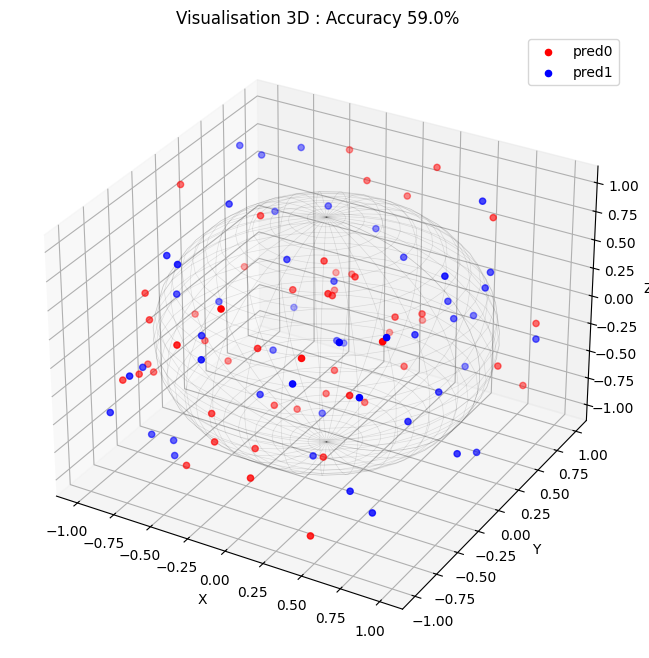

In [85]:

if N_DIM == 2 : 
    plot_2d()
    
elif N_DIM == 3 : 
    plot_3d()
    
    